# Título épico (nose q poner todavía)
> **Integrantes:** Matías Soto, Matías Toledo

Trabajaremos con un dataset de la serie "Pokémon" que desglosa las capacidades de cada criatura en atributos cuantitativos. La tarea consiste en utilizar arquitecturas de redes neuronales simples (MLP) para identificar patrones que distingan a los Pokémon Legendarios del resto.

### Librerías importantes para esta tarea

In [1]:
import torch.nn as nn
import torch
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [2]:
data = pd.read_csv("Pokemon.csv")
data.head()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


---

### Explicacion del dataset

El dataset contiene variables numericas de estadisticas de los Pokemon, como `HP` (puntos de salud), `Attack` (danio de movimientos fisicos), `Defense` (resistencia ante movimientos fisicos), `Sp. Atk` (ataque especial), `Sp. Def` (defensa especial) y `Speed` (velocidad).

Ademas incluye variables categoricas como `Type 1` y `Type 2` (tipo elemental), `Generation` (generacion a la que pertenece) y la variable objetivo `Legendary` (si es legendario o no).

Para este trabajo se considera:

- La columna `#` solo enumera y no aporta informacion.
- La columna `Name` es un identificador unico y no aporta informacion.
- Las variables numericas se mantienen sin cambios.
- `Type 1` y `Type 2` se codifican numericamente.
- `Generation` se mantiene para evaluar su aporte al modelo.
- La variable objetivo `Legendary` se transforma a binaria (0/1).

---

### Preparacion del dataset

1. Se elimina `Name` y `#` por ser identificadores sin valor predictivo.
2. Se convierten `Type 1` y `Type 2` a codigos numericos (en `Type 2`, `NaN` se reemplaza por `None`).
3. Se transforma `Legendary` a 0/1 para clasificacion binaria.
4. Se mantiene `Generation` para evaluar su desempeño en el modelo.
5. Se realiza una primera división del dataset en entrenamiento y prueba.
6. Se realiza una segunda división en el conjunto de entrenamiento para obtener un conjunto de validación independiente y así poder escoger la mejor entre tres arquitecturas sin comprometer el conjunto de test, el cual se reserva exclusivamente para la evaluación final.
7. Se ajusta el `scaler` solo con entrenamiento y se aplica a prueba para evitar data leakage.

Luego se normalizan las variables para que queden en el rango [0, 1].

In [3]:
df = data.copy()

# Variable objetivo binaria
df["Legendary"] = df["Legendary"].astype(int)

# Definir categorias para Type 1 y Type 2
type1_cat = pd.Categorical(df["Type 1"])
type1_categories = list(type1_cat.categories)
type_categories = type1_categories + ["None"]

# Codificacion de Type 1 y mapeo codigo->categoria
print("Type 1 mapeo codigo->categoria:", dict(enumerate(type_categories)))
df["Type 1"] = pd.Categorical(df["Type 1"], categories=type_categories).codes

# Relleno de los faltantes en Type 2 (NaN) por None
type2 = df["Type 2"].fillna("None")

# Codificacion de Type 2 y mapeo codigo->categoria
print("Type 2 mapeo codigo->categoria:", dict(enumerate(type_categories)))
df["Type 2"] = pd.Categorical(type2, categories=type_categories).codes


Type 1 mapeo codigo->categoria: {0: 'Bug', 1: 'Dark', 2: 'Dragon', 3: 'Electric', 4: 'Fairy', 5: 'Fighting', 6: 'Fire', 7: 'Flying', 8: 'Ghost', 9: 'Grass', 10: 'Ground', 11: 'Ice', 12: 'Normal', 13: 'Poison', 14: 'Psychic', 15: 'Rock', 16: 'Steel', 17: 'Water', 18: 'None'}
Type 2 mapeo codigo->categoria: {0: 'Bug', 1: 'Dark', 2: 'Dragon', 3: 'Electric', 4: 'Fairy', 5: 'Fighting', 6: 'Fire', 7: 'Flying', 8: 'Ghost', 9: 'Grass', 10: 'Ground', 11: 'Ice', 12: 'Normal', 13: 'Poison', 14: 'Psychic', 15: 'Rock', 16: 'Steel', 17: 'Water', 18: 'None'}


In [4]:
# Separación de variables y objetivo
X = df.drop(columns=["#","Name", "Legendary"])
y = df["Legendary"]

X.head()

,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation
0,9,13,318,45,49,49,65,65,45,1
1,9,13,405,60,62,63,80,80,60,1
2,9,13,525,80,82,83,100,100,80,1
3,9,13,625,80,100,123,122,120,80,1
4,6,18,309,39,52,43,60,50,65,1


In [5]:
# Guardar indices para poder recuperar Name/# en casos mal clasificados
idx = df.index.values

# Primer split, 80% train, 20% test
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X.values, y.values, idx,
    test_size = 0.2,
    random_state = 42,
    stratify = y.values
)

# Segundo split sobre train para obtener un conjunto extra de validación
X_train, X_val, y_train, y_val, idx_train, idx_val = train_test_split(
    X_train, y_train, idx_train,
    test_size = 0.15 / 0.80,
    random_state = 42,
    stratify = y_train
)

# Normalizacion: ajustar en train y aplicar en test
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Tensores para PyTorch
X_train_tensor = torch.tensor(X_train, dtype = torch.float32)
X_val_tensor = torch.tensor(X_val, dtype = torch.float32)
X_test_tensor = torch.tensor(X_test, dtype = torch.float32)
y_train_tensor = torch.tensor(y_train, dtype = torch.long)
y_val_tensor = torch.tensor(y_val, dtype = torch.long)
y_test_tensor = torch.tensor(y_test, dtype = torch.long)

print(f"Train: {X_train.shape[0]} ejemplos")
print(f"Val: {X_val.shape[0]} ejemplos")
print(f"Test: {X_test.shape[0]} ejemplos")

Train: 520 ejemplos
Val: 120 ejemplos
Test: 160 ejemplos


---

### Definicion del modelo

Se definen 3 modelos de redes neuronales de multiperceptron, presentes en el archivo `models.py`, los cuales son:

- `MLP_Arquitectura1`: 1 capa oculta (16 neuronas) con funcion de activacion Sigmoid; es el modelo mas simple y de menor capacidad.
- `MLP_Arquitectura2`: 2 capas ocultas (32 y 16 neuronas) con funcion de activacion ReLU (Rectified Linear Unit); modelo mas profundo.
- `MLP_Arquitectura3`: 2 capas ocultas (64 y 32 neuronas) con funcion de activacion ReLU y Dropout(0.3) (Técnica regularización que aleatoriamente apaga el 30% de las neuronas); modelo con mayor capacidad y regularizacion para evitar sobreajuste.

#### Variables de iniciacion

Para la iniciacion de estos modelos, se definen estas variables:

- `input_dim = 10`: corresponde al numero de variables de entrada.
- `output_dim = 2`: corresponde a las dos clases de salida (legendario y no legendario).

In [6]:
# Importamos las tres arquitecturas desde models.py
from models import MLP_Arquitectura1, MLP_Arquitectura2, MLP_Arquitectura3

modelo1 = MLP_Arquitectura1(input_dim = 10, output_dim = 2)
modelo2 = MLP_Arquitectura2(input_dim = 10, output_dim = 2)
modelo3 = MLP_Arquitectura3(input_dim = 10, output_dim = 2)


for nombre, modelo in [("Arquitectura 1", modelo1), ("Arquitectura 2", modelo2), ("Arquitectura 3", modelo3)]:
    n_params = sum(p.numel() for p in modelo.parameters())
    print(f"=== {nombre} ===")
    print(modelo)
    print(f"Parámetros totales: {n_params}\n")

=== Arquitectura 1 ===
MLP_Arquitectura1(
  (hidden): Linear(in_features=10, out_features=16, bias=True)
  (activation): Sigmoid()
  (output): Linear(in_features=16, out_features=2, bias=True)
)
Parámetros totales: 210

=== Arquitectura 2 ===
MLP_Arquitectura2(
  (hidden1): Linear(in_features=10, out_features=32, bias=True)
  (hidden2): Linear(in_features=32, out_features=16, bias=True)
  (activation): ReLU()
  (output): Linear(in_features=16, out_features=2, bias=True)
)
Parámetros totales: 914

=== Arquitectura 3 ===
MLP_Arquitectura3(
  (hidden1): Linear(in_features=10, out_features=64, bias=True)
  (hidden2): Linear(in_features=64, out_features=32, bias=True)
  (activation): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
  (output): Linear(in_features=32, out_features=2, bias=True)
)
Parámetros totales: 2850



---

### Definicion de optimizador y funcion de costo

#### Optimizador

Se elige `Adam` por que combina momento y tasasa adaptativas, lo cual acelera la convergencia y suele funcionar bien sun mucha sintonización inicial.

- `lr`: tasa de aprendizaje.
- `betas`: coeficientes para los momentos.
- `weight_decay`: regularizacion L2 de los parametros, para reducir sobreajuste (se deja en `weight_decay = 0` para no mezclar regularización L2 con Dropout)

#### Funcion de costo

Se usa `CrossEntropyLoss`, adecuada para clasificacion multiclase con salidas sin activar (logits).

La perdida para una muestra se expresa como:

$$
\mathcal{L}(y, \hat y) = -\sum_{c=1}^{C} y_c \log(\hat y_c)
$$

donde $y_c$ es la etiqueta verdadera (one-hot) y $\hat y_c$ es la probabilidad predicha por el modelo para la clase $c$.

#### Optimizador

Se usa `Adam`, el cual es un algoritmo de optimización con tasa de gradiente adaptativa donde:

- `lr`: tasa de aprendizaje.
- `betas`: coeficientes para los momentos.
- `weight_decay`: regularizacion L2 de los parametros, para reducir sobreajuste.

> Se define un optimizador para cada modelo con los mismos hiperparámetros para que la comparación sea justa

> Además, se utiliza weight_decay = 1e-4 en todos los optimizadores como regularización L2, para reducir el sobreajuste al penalizar pesos grandes. Se aplica a los tres modelos para que la comparación sea justa.

In [7]:
# Funcion de costo
criterion = torch.nn.CrossEntropyLoss(reduction = 'mean')

# Optimizadores para los 3 modelos
optimizer1 = torch.optim.Adam(modelo1.parameters(), lr = 1e-3, weight_decay = 1e-4)
optimizer2 = torch.optim.Adam(modelo2.parameters(), lr = 1e-3, weight_decay = 1e-4)
optimizer3 = torch.optim.Adam(modelo3.parameters(), lr = 1e-3, weight_decay = 1e-4)

---

### Entrenamiento de los modelos

Se entrenan los tres modelos durante 300 épocas usando el mismo optimizador (Adam, lr = 1e-3) y función de costo (CrossEntropyLoss) para las tres diferentes arquitecturas para asegurar una comparación justa. La métrica para escoger el mejor modelo será el **F1-score**, por lo que se calcula esta métrica en cada época sobre el conjunto de validación. Al final, se escoge la arquitectura con mayor F1-score en validación.

Se usan 300 épicas debido al tamaño del dataset. El conjunto de entrenamiento tiene aproximadamente ~640 ejemplos, por lo que converge rápido. Se monitorea la curva de loss para verificar convergencia.

In [8]:
from sklearn.metrics import f1_score

def entrenar_modelo(
    modelo, optimizer, 
    X_train, y_train, X_val, y_val, 
    criterion, epochs = 300
):
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        # --- Entrenamiento ---
        modelo.train()
        optimizer.zero_grad()
        logits = modelo(X_train)
        loss = criterion(logits, y_train)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

        # --- Validación ---
        modelo.eval()
        with torch.no_grad():
            logits_val = modelo(X_val)
            loss_val = criterion(logits_val, y_val)
            val_losses.append(loss_val.item())

    return train_losses, val_losses

# Entrenamiento del modelo 1
tl1, vl1 = entrenar_modelo(
    modelo1, optimizer1, 
    X_train_tensor, y_train_tensor,
    X_val_tensor, y_val_tensor, criterion
)

# Entrenamiento del modelo 2
tl2, vl2 = entrenar_modelo(
    modelo2, optimizer2,
    X_train_tensor, y_train_tensor,
    X_val_tensor, y_val_tensor, criterion
)

# Entrenamiento del modelo 3
tl3, vl3 = entrenar_modelo(
    modelo3, optimizer3,
    X_train_tensor, y_train_tensor,
    X_val_tensor, y_val_tensor, criterion
)

Una vez entrenados los tres modelos, observamos sus curvas de loss y calculamos sus F1-scores para así determinar cuál es la mejor:

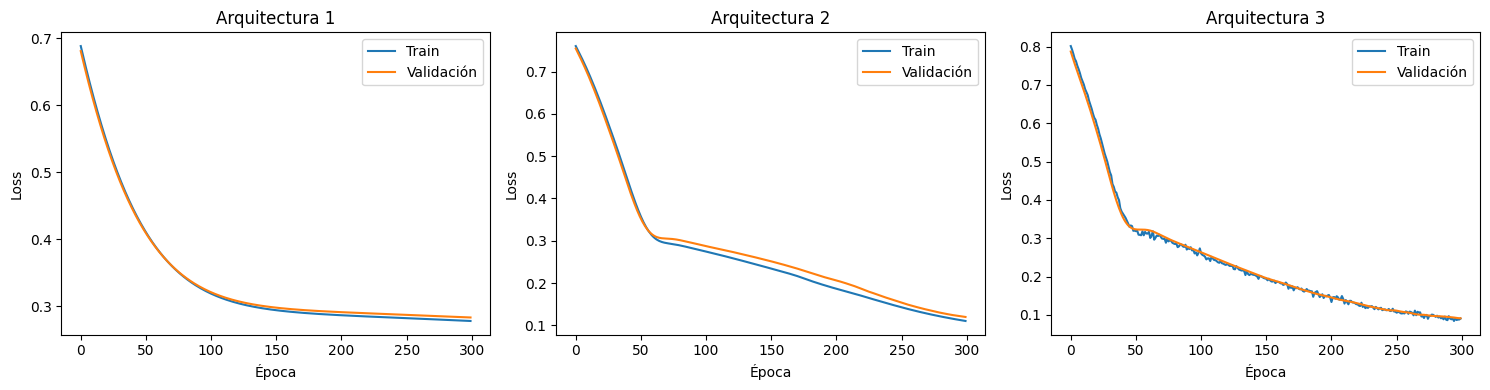

=== Comparación en validación ===
Arquitectura 1 — F1: 0.0000 | Val Loss final: 0.2829
Arquitectura 2 — F1: 0.7059 | Val Loss final: 0.1197
Arquitectura 3 — F1: 0.7778 | Val Loss final: 0.0911

Modelo seleccionado: Arquitectura 3


In [9]:
# Curvas de loss
fig, axes = plt.subplots(1, 3, figsize = (15, 4))
for ax, tl, vl, nombre in zip(axes, [tl1, tl2, tl3], [vl1, vl2, vl3],
                            ["Arquitectura 1", "Arquitectura 2", "Arquitectura 3"]
):
    ax.plot(tl, label = "Train")
    ax.plot(vl, label = "Validación")
    ax.set_title(nombre)
    ax.set_xlabel("Época")
    ax.set_ylabel("Loss")
    ax.legend()

plt.tight_layout()
plt.show()

# F1-score en validación para cada arquitectura
def f1_en_validacion(modelo, X_val, y_val):
    modelo.eval()
    with torch.no_grad():
        preds = modelo(X_val).argmax(dim = 1).numpy()
    return f1_score(y_val.numpy(), preds)

f1_1 = f1_en_validacion(modelo1, X_val_tensor, y_val_tensor)
f1_2 = f1_en_validacion(modelo2, X_val_tensor, y_val_tensor)
f1_3 = f1_en_validacion(modelo3, X_val_tensor, y_val_tensor)

print("=== Comparación en validación ===")
print(f"Arquitectura 1 — F1: {f1_1:.4f} | Val Loss final: {vl1[-1]:.4f}")
print(f"Arquitectura 2 — F1: {f1_2:.4f} | Val Loss final: {vl2[-1]:.4f}")
print(f"Arquitectura 3 — F1: {f1_3:.4f} | Val Loss final: {vl3[-1]:.4f}")

mejor = {f1_1: "Arquitectura 1", f1_2: "Arquitectura 2", f1_3: "Arquitectura 3"}

# Seleccionamos la que tenga el mejor F1-Score
print(f"\nModelo seleccionado: {mejor[max(f1_1, f1_2, f1_3)]}")

#### Interpretación

* **Arquitectura 1:** 

* **Arquitectura 2:** 

* **Arquitectura 3:** 

---

### Evaluación del modelo

Se evalua el rendimiento en el conjunto de prueba usando metricas como exactitud y matriz de confusion.

#### Exploración casos mal clasificados

In [11]:
# Elegir el modelo final (ajusta si corresponde)
modelo = modelo2

modelo.eval()
with torch.no_grad():
    logits_test = modelo(X_test_tensor)
    preds_test = logits_test.argmax(dim=1).cpu().numpy()

# Falsos positivos (predijo 1, era 0) y falsos negativos (predijo 0, era 1)
fp_idx = (preds_test == 1) & (y_test == 0)
fn_idx = (preds_test == 0) & (y_test == 1)

# Ejemplo de FP
if fp_idx.any():
    i = fp_idx.nonzero()[0][0]
    idx_real = idx_test[i]
    print("FP -> real:", y_test[i], "pred:", preds_test[i])
    print(df.loc[idx_real, ["#", "Name", "Type 1", "Type 2", 
                            "HP", "Attack", "Defense", 
                            "Sp. Atk", "Sp. Def", "Speed",
                            "Legendary"]])
else:
    print("No hay falsos positivos en test")
print("------------------------------------------------")
# Ejemplo de FN
if fn_idx.any():
    i = fn_idx.nonzero()[0][0]
    idx_real = idx_test[i]
    print("FN -> real:", y_test[i], "pred:", preds_test[i])
# HP	Attack	Defense	Sp. Atk	Sp. Def	Speed
    print(df.loc[idx_real, ["#", "Name", "Type 1", "Type 2", 
                            "HP", "Attack", "Defense", 
                            "Sp. Atk", "Sp. Def", "Speed",
                            "Legendary"]])
else:
    print("No hay falsos negativos en test")

FP -> real: 0 pred: 1
#                                282
Name         GardevoirMega Gardevoir
Type 1                            14
Type 2                             4
HP                                68
Attack                            85
Defense                           65
Sp. Atk                          165
Sp. Def                          135
Speed                            100
Legendary                          0
Name: 306, dtype: object
------------------------------------------------
FN -> real: 1 pred: 0
#                146
Name         Moltres
Type 1             6
Type 2             7
HP                90
Attack           100
Defense           90
Sp. Atk          125
Sp. Def           85
Speed             90
Legendary          1
Name: 158, dtype: object


---

### Preguntas finales

**1. Sobre la matriz de confusion, interprete los resultados obtenidos. Con sus palabras defina que significa cada tipo de error. ?Elegiria a Pokemon ubicados en FP o FN para su equipo?**

**Recordatorio (clase positiva: Legendary):**

- **TP (verdadero positivo):** predicho Legendary y realmente Legendary.
- **TN (verdadero negativo):** predicho no Legendary y realmente no Legendary.
- **FP (falso positivo):** predicho Legendary pero realmente no Legendary.
- **FN (falso negativo):** predicho no Legendary pero realmente Legendary.
- **Precision:** $TP/(TP+FP)$, de los Legendary predichos, cuantos eran correctos.
- **Recall (sensibilidad):** $TP/(TP+FN)$, de los Legendary reales, cuantos detecto el modelo.


**2. Busque un caso mal clasificado por el modelo, e interprete por qué cree que el modelo se equivocó en ese caso.**

Uno de los casos mal clasificados es el de Mega Gardevoir, un pokemon con estadisticas muy altas que no es legendario (modelo lo clasifica como legendario, siendo un FP).

Por esto, el vector de este pokemon "pseudo-legendario" se parece mucho al de un pokemon legendario.

Otra razon puede ser la poca cantidad de pokemones legendarios del dataset (por ende pocos datos con los que aprender) o que este dataset tambien solo tiene tipos y stats (por ende no aprende de habilidades o lore).

**3. ¿Cúal fue el mayor desafío que enfrentó al realizar esta tarea? ¿Cómo lo solucionó?**


### IA Generativa
**1. ¿Utilizó alguna herramienta de IA Generativa para realizar esta tarea? En caso afirmativo, indique cuál o cuáles herramientas utilizó.**

Para esta tarea se hicieron uso de Claude (modelo Sonnet 4.6) y ChatGPT Codex (modelo GPT-5.2-Codex).

**2. ¿En qué parte o partes de la tarea utilizó estas herramientas?**

Se uso en partes iniciales de la tarea, principalmente para entender mejor el material visto en clases, y así aplicar los procedimientos correctamente a esta tarea.